# 描述
做一个简单的车牌号码提取的代码

In [1]:
import cv2
import numpy as np

## 定义一个图像预处理的相关代码

In [2]:
def preprocess(gray):
    """
    对灰度对象进行形态转换（预处理）
    :param gray:
    :return:
    """
    # 高斯平滑
    gaussian = cv2.GaussianBlur(gray, (3, 3), 0, 0, cv2.BORDER_DEFAULT)

    # 中值滤波
    median = cv2.medianBlur(gaussian, 5)

    # Sobel算子，对边缘进行处理(获取边缘信息，其实就是卷积过程)
    # x：[-1, 0, +1, -2, 0, +2, -1, 0, +1]
    # y：[-1, -2, -1, 0, 0, 0, +1, +2, +1]
    sobel = cv2.Sobel(median, cv2.CV_64F, dx=1, dy=0, ksize=3)
    # 类型转换为unit8
    sobel = np.uint8(np.absolute(sobel))

    # 二值化
    ret, binary = cv2.threshold(sobel, 170, 255, cv2.THRESH_BINARY)

    # 膨胀&腐蚀
    element1 = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 1))
    element2 = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 7))
    # 膨胀一次，让轮廓突出
    dilation = cv2.dilate(binary, element2, iterations=1)
    # 腐蚀一次，去掉细节
    erosion = cv2.erode(dilation, element1, iterations=2)
    # 再次膨胀，让轮廓明显一些
    dilation2 = cv2.dilate(erosion, element2, iterations=5)
    # 腐蚀一次，去掉细节
    erosion2 = cv2.erode(dilation2, element1, iterations=4)

#     cv2.imshow('gray', gray)
#     cv2.imshow('gaussian', gaussian)
#     cv2.imshow('median', median)
#     cv2.imshow('sobel', sobel)
#     cv2.imshow('binary', binary)
#     cv2.imshow('dilation', dilation)
#     cv2.imshow('erosion', erosion)
#     cv2.imshow('dilation2', dilation2)
#     cv2.imshow('erosion2', erosion2)
#     cv2.waitKey(0)
#     cv2.destroyAllWindows()
    return erosion2

In [33]:
img = cv2.imread("car.jpg", 0)
img = cv2.imread("car6.jpeg", 0)
preprocess(img)
0

0

## 进行车牌照区域查找

In [3]:
def find_plate_number_region(img):
    """
    寻找可能是车牌区域的轮廓
    :param img:
    :return:
    """
    # 查找轮廓(img: 原始图像，contours：矩形坐标点，hierarchy：图像层次)
    contours, hierarchy = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # 查找矩形
    max_ratio = -1
    max_box = None
    ratios = []
    number = 0
    for i in range(len(contours)):
        cnt = contours[i]  # 当前轮廓的坐标信息

        # 计算轮廓面积
        area = cv2.contourArea(cnt)
        # 面积太小的过滤掉
        if area < 10000:
            continue

        # 找到最小的矩形
        rect = cv2.minAreaRect(cnt)

        # 矩形的四个坐标（顺序不定，但是一定是一个左下角、左上角、右上角、右下角这种循环顺序(开始是哪个点未知)）
        box = cv2.boxPoints(rect)
        # 转换为long类型
        box = np.int64(box)
        
        
        # 计算长宽高
        # 计算第一条边的长度
        a = abs(box[0][0] - box[1][0])
        b = abs(box[0][1] - box[1][1])
        h = np.sqrt(a ** 2 + b **2)
        # 计算第二条边的长度
        c = abs(box[1][0] - box[2][0])
        d = abs(box[1][1] - box[2][1])
        w = np.sqrt(c ** 2 + d **2)
        # 让最小值为高度，最大值为宽度
        height = int(min(h, w))
        weight = int(max(h, w))
        
        # 计算面积
        area2 = height * weight
        
        # 两个面积的差值一定在一定范围内
        r = np.absolute((area2 - area) / area)
        if r > 0.6:
            continue
        
        ratio = float(weight) / float(height)
        print((box, height, weight, area, area2, r, ratio, rect[-1]))
        cv2.drawContours(img, [box], 0, 255, 2)
        cv2.imshow('img', img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        # 实际情况下ratio应该是3左右，但是由于我们的照片不规范的问题，
        # 检测出来的宽度比高度应该在2~5.5之间
        if ratio > max_ratio:
            max_box = box
            max_ratio = ratio

        if ratio > 5.5 or ratio < 2:
            continue

        
        number += 1
        ratios.append((box, ratio))

    

    # 根据找到的图像矩阵数量进行数据输出
    print("总共找到:{}个可能区域!!".format(number))
    if number == 1:
        # 直接返回
        return ratios[0][0]
    elif number > 1:
        # 不考虑太多，直接获取中间值(并且进行过滤)
        # 实际要求更加严格
        filter_ratios = list(filter(lambda t: t[1] >= 2.7 and t[1] <= 5.0, ratios))
        size_filter_ratios = len(filter_ratios)
        
        if size_filter_ratios == 1:
            return filter_ratios[0][0]
        elif size_filter_ratios > 1:
            # 获取中间值
            ratios1 = [filter_ratios[i][1] for i in range(size_filter_ratios)]
            ratios1 = list(zip(range(size_filter_ratios), ratios1))
            # 数据排序
            ratios1 = sorted(ratios1, key=lambda t: t[1])
            # 获取中间值的数据
            idx = ratios1[size_filter_ratios // 2][0]
            return filter_ratios[idx][0]
        else:
            # 获取最大值
            ratios1 = [ratios[i][1] for i in range(number)]
            ratios1 = list(zip(range(number), ratios1))
            # 数据排序
            ratios1 = sorted(ratios1, key=lambda t: t[1])
            # 获取最大值的数据
            idx = ratios1[-1][0]
            return filter_ratios[idx][0]
    else:
        # 直接返回最大值
        print("直接返回最接近比例的区域...")
        return max_box

## 进行车牌的截取

In [4]:
def cut(img_or_img_path):
    """
    截取车牌区域
    :param img:
    :return:
    """
    if isinstance(img_or_img_path, str):
        img = cv2.imread(img_or_img_path)
    else:
        img = img_or_img_path
    
    # 获取图像的高度和宽度
    rows, cols, _ = img.shape

    # 将图像转换为灰度图
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 图像预处理-->将车牌区域给明显的显示出来
    dilation = preprocess(gray)

    # 查找车牌区域(假定只会有一个)
    box = find_plate_number_region(dilation)

    # 返回区域对应的图像
    # 因为不知道，点的顺序，所以对左边点坐标排序
    ys = [box[0, 1], box[1, 1], box[2, 1], box[3, 1]]
    xs = [box[0, 0], box[1, 0], box[2, 0], box[3, 0]]
    ys_sorted_index = np.argsort(ys)
    xs_sorted_index = np.argsort(xs)

    # 获取x上的坐标
    x1 = box[xs_sorted_index[0], 0]
    x1 = x1 if x1 > 0 else 0
    x2 = box[xs_sorted_index[3], 0]
    x2 = cols if x2 > cols else x2

    # 获取y上的坐标
    y1 = box[ys_sorted_index[0], 1]
    y1 = y1 if y1 > 0 else 0
    y2 = box[ys_sorted_index[3], 1]
    y2 = rows if y2 > rows else y2

    # 截取图像
    img_plate = img[y1:y2, x1:x2]

    return img_plate

In [6]:
path = 'car.jpg'
cut_img = cut(path)
print(cut_img.shape)
cv2.imwrite(f'plat_{path}', cut_img)

# 可视化
cv2.imshow('image', cv2.imread(path))
cv2.imshow('plat', cut_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

(array([[118, 225],
       [371, 221],
       [373, 309],
       [119, 312]], dtype=int64), 88, 253, 20075.0, 22264, 0.10904109589041096, 2.875, 89.26547241210938)
总共找到:1个可能区域!!
(91, 255, 3)


### 下列代码仅支持car2.jpg这个图像

In [36]:
cut_img = cut_img

# 旋转
rows, cols, _ = cut_img.shape
M = cv2.getRotationMatrix2D(center=(cols/2, rows/2), angle=-4.808, scale=1)
cut_img2 = cv2.warpAffine(cut_img, M, (cols, rows), borderValue=[0,0,0])


gray = cv2.cvtColor(cut_img2, cv2.COLOR_BGR2GRAY)
# 高斯平滑
gaussian = cv2.GaussianBlur(gray, (3, 3), 0, 0, cv2.BORDER_DEFAULT)

# 中值滤波
median = cv2.medianBlur(gaussian, 5)

# 边缘检测
edges = cv2.Canny(median,threshold1=50, threshold2=250)

# 二值化
ret, binary = cv2.threshold(edges, 170, 255, cv2.THRESH_BINARY)

# 膨胀一次，让轮廓突出
element2 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
dilation = cv2.dilate(binary, element2, iterations=1)

cv2.imshow('cut_img', cut_img)
cv2.imshow('cut_img2', cut_img2)
cv2.imshow('binary', binary)
cv2.imshow('dilation', dilation)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [8]:
cv2.imwrite('car2_plat.jpg', cut_img2)


True

In [9]:
v = binary
v = np.mean(v, axis=0)  # 将图像每列取均值
v = v * 2.5
v = v.astype(np.uint8)
vv = np.array([
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v
])
cv2.imshow('vv', vv)
cv2.waitKey(0)
cv2.destroyAllWindows()

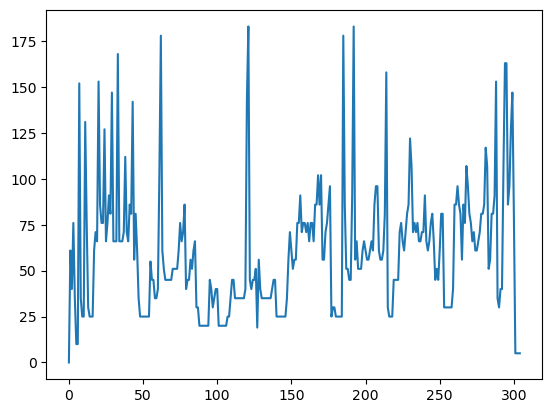

In [10]:
import matplotlib.pyplot as plt

plt.plot(v)
plt.show()